Usando fashion como dataset
Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - kl_loss: 5.6017 - loss: 44.1505 - reconstruction_loss: 38.5562 - val_kl_loss: 5.8689 - val_loss: 35.3156 - val_reconstruction_loss: 29.4541
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - kl_loss: 5.2367 - loss: 32.6661 - reconstruction_loss: 27.4298 - val_kl_loss: 4.7872 - val_loss: 31.3901 - val_reconstruction_loss: 26.7178
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - kl_loss: 4.8640 - loss: 30.5688 - reconstruction_loss: 25.7057 - val_kl_loss: 4.7420 - val_loss: 30.0990 - val_reconstruction_loss: 25.3988
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - kl_loss: 4.8642 - loss: 29.5108 - reconstruction_loss: 24.6465 - val_kl_loss: 4.9566 - val_loss: 29.3161 - val_reconstruction_loss: 24.4915
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - kl_loss: 4.9624 - loss: 29.0222 - reconstruction_loss: 24.0598 - val_kl_loss: 4.8361 - val_loss: 28.8578 - val_reconstruct

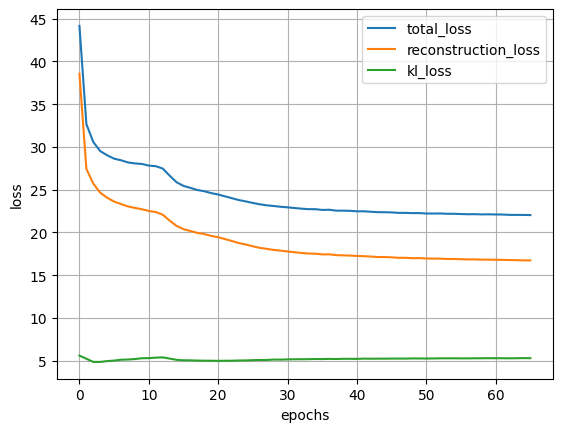

In [4]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))

from data.get_data import get_mnist_data
from models_definitions import encoder
from models_definitions import decoder
from models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping


dataset="fashion"
data = get_mnist_data(dataset=dataset)

x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]

original_dim = 28*28
beta = 1.0

train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)


#intermediate_dim=[128,128,256,256,512,512,1024,1024]
#latent_dim=[2,64,64,128,128,256,256,512]
intermediate_dim=[1024]
latent_dim=[512]


for i in range(len(intermediate_dim)):

    # === 1) Crear modelos nuevos y sin estado ===
    en = encoder.build_enconder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )
    de = decoder.build_decoder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )

    # === 2) Crear un CVAE fresco ===
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=original_dim,
        beta=beta,
    )

    # === 3) Nuevo optimizador por cada modelo ===
    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)

    # === 4) Resetear métricas (OBLIGATORIO en modelos subclassed) ===
    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # === 5) Entrenar ===
    history = cvae_model.fit(
        train_dataset,
        epochs=1000,
        batch_size=128,
        validation_data=val_dataset,
        callbacks=[early_stopping],
        verbose=1
    )

    # === 6) Guardar ===
    en.save(f"en_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")
    de.save(f"de_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")

    # === 7) Graficar ===
    plt.plot(history.history["loss"], label="total_loss")
    plt.plot(history.history["reconstruction_loss"], label="reconstruction_loss")
    plt.plot(history.history["kl_loss"], label="kl_loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.legend()
    plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
    plt.show()

CROP-1 consta de 2 modelos entrenados por separados con imagnes limpias que interactuan entre sí con el fin de separa mezclas de imagenes. Por un lado un autoeoncder variacional condicional (CVAE) cuyo objetivo es reconstruir una imagen a partir de una imagen de input y dos condiciones (en general son iguales) y una red convolucional capaz de aprender representaciones para clasificar las imagenes. 


## Auto Encoder

### Encoder
Los autoencoder son redes neuronales de tipo Enconder-Decoder con el fin de generar output igual al input. 
Los Encoders comprimen las imagenes en varios pasos hasta alcanzar una representación en el espacion latente. 
En este caso, la imagen input se apalana y se concatena con las condición del encoder (input_concat) que se pasa a una capa densa de dimensión "intermediate_dim" (por defecto 128) y luego se pasa por otra capa densa cuya salida es de dimensión laten_dim (por defecto 2).

### Decoder
Los Decoders generan un output a partir del espacio latente usando "descomprimendo" el output en dimensiones cada vez mayores hasta alcanzar un resultado de una dimensión igual a la del input. En este caso, la entrada del decoder es el espacio latente, generado por el encoder, concatenado con la condición del decoder. Este decoder_input, es usado en una capa densa cuya salida es un vector de dimesión "intermediate_dim" (igual que en el encoder) y finalmente la salida del decoder es una vector de dimensión igual a la de entrada (28*28).

## Auto Encoder Variacional
A diferencia el los autoencoders, los autoencoder variacionales tienen como obejtivo aprender representaciones y generar pequeñas variaciones las entradas. Esto se logra usando una estructura clásica de encoder-decoder pero remplazando el espacio latente por una representación probabilistica. 
De esa manera. El enconder logra mapear el espacio de los inputs a distribuciones en el espacio latente y el decoder mapea esas distribuciones nuevamente al espacio de entrada. 
Para entrenar estos modelos, es necesario introducir dos metricas de error. Por una lado tenemos el error de reconstrucción que mide la calidad de los outputs generados contra los inputs. Por otro lado tenemos la divergencia Kullback–Leibler que mide la diferencia entre la distribución de la represensión de los datos en el espacio latente y una gaussiana. La función de coste es la suma de estos dos errores. Adicionlamente, el coste KL se multiplica por un factor Beta(en nuestro caso 1).
En estas arquitecturas para poder seguir usando backpropagation como método de ajuste de pesos, es necesario hacer un muestro del espacio latente, por lo que ademas del espacio latente z tenemos z_mu y z_var. //entender para que se usan


# Auto Encoder Variacional Condicional (CVAE)
Un auto Encoder Variacional Condicional es VAE al que se le agrega un vector de condiciones para controlar el output generado, un promt. El espacio latente ahora no necesita aprender clases, parende estrucutras como formas ne lugar de clases. Cualquier punto del espacio latente puede ser usando para generar cualquier imagen dada la condción del decoder.


## Resumen de parametros destacados:
- Dimensión del espacio latente: 2 (por defecto, se puede elegir) 
- Dimensión intermedia: 128 (por defecto)
- Beta 1
- Dimensión de entrada, 28*28
- 10 clases en el data set --> Vector de condiciones de 10.


## Predictor
El predictor o clasificador es una red neuronal convolucional con el fin de aprender representaciones de las distitnas clases.
## Parametros de interes:
Función de activacion softmax para que el output sea una probabilidad
batchnormalization (buscar)
dropout de 0.5 (buscar)



### Modelo CROP-1:

El modelo funciona con la interacción de los otros modelos explicados anteriormente con el fin de, dada una imagen mezcla, obtener las dos imagenes limpias.


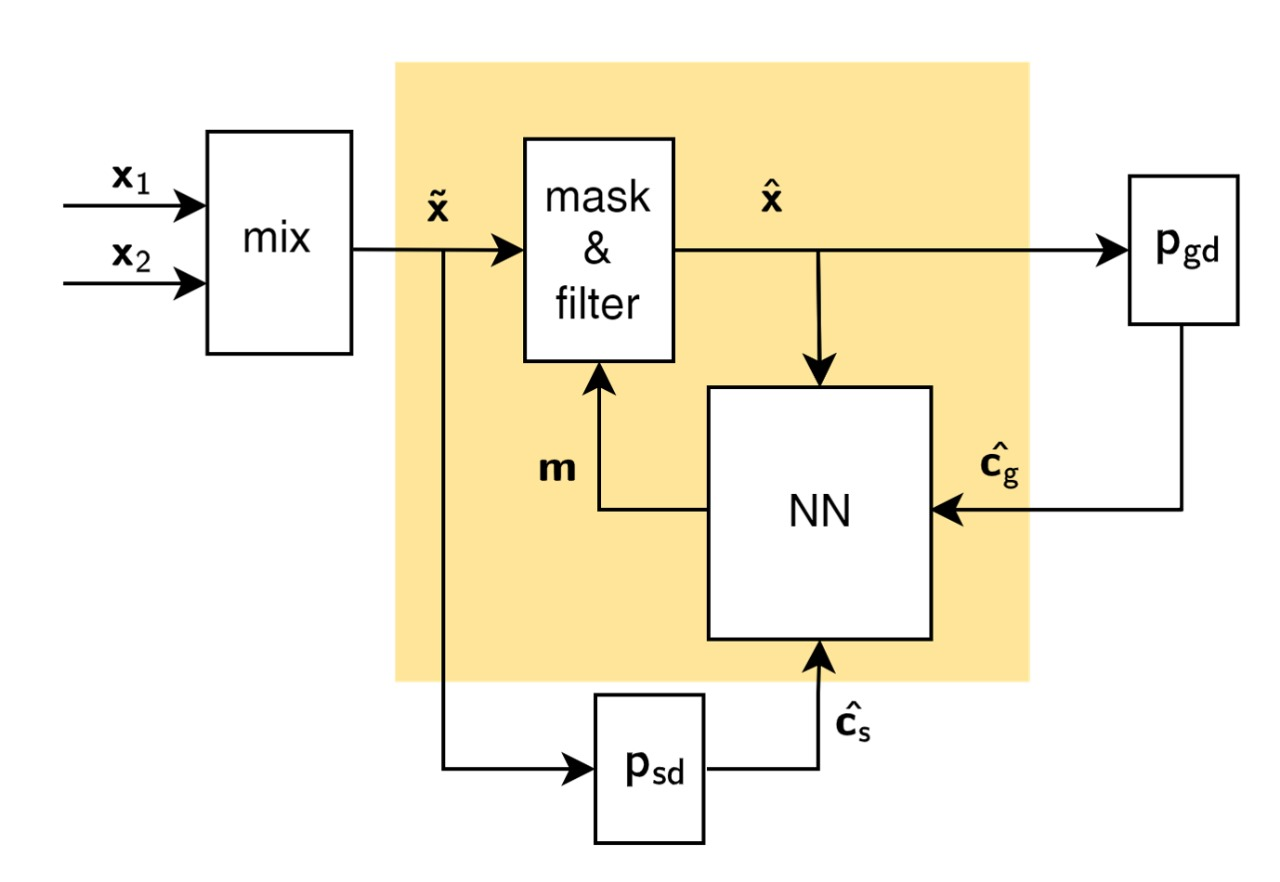

En un primer instante, la imagen mezcla $ x^~ $ es alimentada a Psd (modelo predictor) para geenrar la condición que es input del CVAE Cs. a su vez la imagen muestra se procesa con mascaras y/o filtros (en la primera pasada no hay ni mascaras ni filtros, la imagen pasa limpia) x ^. Esta imagen, junto con la condición alimentan a la CVAE el cual genera una imagen del dígito predicho (el indicado por Cs) la cual se usa como mascara de para la próxima iteración. 
Durante las siguientes iteraciones la estimación del digito más probable queda a cargo del bloque Pgd qeu genera la condición Cg la cual alimenta el CVAE. Mientras tanto la salida m de la iteración i-1 se usa como máscara para la salida de la iteración i para genera x^, lo cual vuelve a arrancar el ciclo. 

